In [ ]:
# we will build our own ANN
#structure
# input layer (784) -> first hidden layer (128) -> second hidden layer -> output(10)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv('/content/fmnist_small.csv')

In [4]:
df.shape

(6000, 785)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 35.9 MB


In [9]:
df.head(0)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784


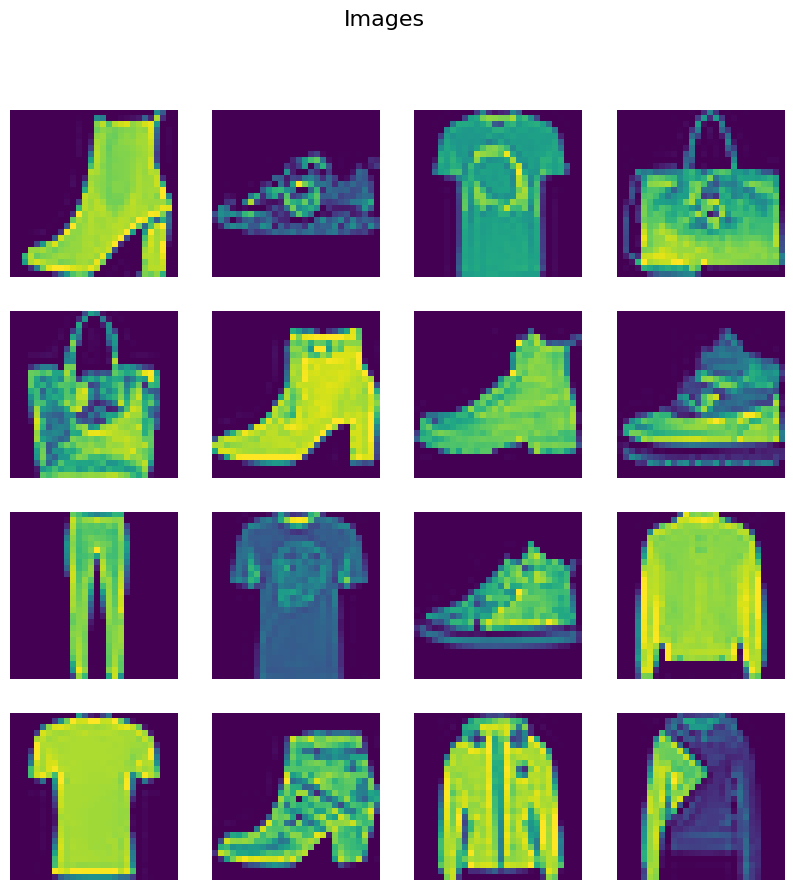

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Images', fontsize=16)

for i, ax in enumerate(axes.flat):
    image = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(image)
    ax.axis('off')


plt.show()



In [11]:
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


In [14]:
df.iloc[:, 0]

,label
0,9
1,7
2,0
3,8
4,8
...,...
5995,1
5996,5
5997,8
5998,4


In [15]:
df.iloc[:, 1:].values

array([[  0,   0,   0, ..., 165,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]])

In [16]:
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [18]:
# scaling the features
x_train = x_train/255.0
x_test = x_test/255.0

In [19]:
# creating a dataclass
class customDataet(Dataset):
    def __init__(self, features, labels):
        super().__init__()
        self.features = torch.tensor(features , dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [20]:
# creating train_dataset object
train_dataset = customDataet(x_train, y_train)

In [21]:
len(train_dataset)

4800

In [22]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [23]:
test_dataset = customDataet(x_test, y_test)

In [24]:
# now with the help of dataset objects, we create dataloader objects
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle = False)

In [26]:
class myNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
            # we don't need to define softmax explicitly in pytorch
        )

    def forward(self, x):
        return self.model(x)

In [27]:
# set learning rate and epochs
learning_rate = 0.1
epochs = 100

In [28]:
# model instantiation
model = myNN(x_train.shape[1])

# loss function
my_loss = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [34]:
train_dataloader
for i in train_dataloader:
    print(i)
    break

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([4, 1, 5, 9, 5, 4, 5, 0, 9, 3, 6, 5, 4, 9, 3, 6, 2, 7, 7, 7, 7, 6, 1, 1,
        2, 8, 4, 9, 2, 9, 9, 2])]


In [35]:
train_dataloader.batch_size

32

In [36]:
# training loop
for epoch in range(epochs):
    # for each batch i am doing this
    total_epoch_loss = 0
    for batch_feature, batch_labels in train_dataloader:
        # forward
        pred = model(batch_feature)
        # loss cal
        Loss = my_loss(pred, batch_labels)
        # backward
        optimizer.zero_grad()
        Loss.backward() # yaha par gradients calculate ho gaye
        # gradient update
        optimizer.step()

        total_epoch_loss += Loss.item()
    #printing avg loss
    print(f'Epoch: {epoch+1}, Loss: {total_epoch_loss/len(train_dataloader)}')

Epoch: 1, Loss: 1.3210839076836904
Epoch: 2, Loss: 0.7711651494105657
Epoch: 3, Loss: 0.6498966403802235
Epoch: 4, Loss: 0.5782989227771759
Epoch: 5, Loss: 0.5260264125466346
Epoch: 6, Loss: 0.4979198008775711
Epoch: 7, Loss: 0.4696861114104589
Epoch: 8, Loss: 0.4482481747865677
Epoch: 9, Loss: 0.43081409911314644
Epoch: 10, Loss: 0.4018834148844083
Epoch: 11, Loss: 0.3914003053307533
Epoch: 12, Loss: 0.36398091276486716
Epoch: 13, Loss: 0.35344036971529325
Epoch: 14, Loss: 0.3370693395535151
Epoch: 15, Loss: 0.3300842507183552
Epoch: 16, Loss: 0.31191400716702145
Epoch: 17, Loss: 0.300431623707215
Epoch: 18, Loss: 0.2905162205795447
Epoch: 19, Loss: 0.2766142308960358
Epoch: 20, Loss: 0.26828524048129715
Epoch: 21, Loss: 0.2578363628933827
Epoch: 22, Loss: 0.2497176836927732
Epoch: 23, Loss: 0.24695447226365408
Epoch: 24, Loss: 0.24638961469133694
Epoch: 25, Loss: 0.22851635865867137
Epoch: 26, Loss: 0.20853849264482657
Epoch: 27, Loss: 0.21090926503141721
Epoch: 28, Loss: 0.204699716

In [37]:
# evaluate model
# pehle model ko evaluation mode me set krna hota hai
model.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# why we do this?


In [38]:
total = 0
correct = 0

with torch.no_grad():
    for batch_feature, batch_labels in test_dataloader:
        pred = model(batch_feature)
        _, predicted = torch.max(pred, 1)
        total += batch_labels.size(0)

        correct += (predicted == batch_labels).sum().item()
print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))



Accuracy of the network on the 10000 test images: 83 %


In [ ]:
# improving the accuracy

In [40]:
torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device(type='cuda')